In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape(-1, 784)
test_images = test_images.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
def create_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "Adagrad": tf.keras.optimizers.Adagrad(),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

In [ ]:
history_dict = {}
results = {}

for name, opt in optimizers.items():
    model = create_model()
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_images, train_labels,
                        epochs=5,
                        batch_size=64,
                        validation_data=(test_images, test_labels),
                        verbose=0)

    history_dict[name] = history

    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    results[name] = (test_loss, test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
for name, (loss, acc) in results.items():
    print(f"{name} --> Loss: {loss:.4f}, Accuracy: {acc:.4f}")

SGD --> Loss: 0.2259, Accuracy: 0.9360
Momentum --> Loss: 0.0886, Accuracy: 0.9713
Adagrad --> Loss: 0.4064, Accuracy: 0.8907
RMSProp --> Loss: 0.1092, Accuracy: 0.9685
Adam --> Loss: 0.0810, Accuracy: 0.9762


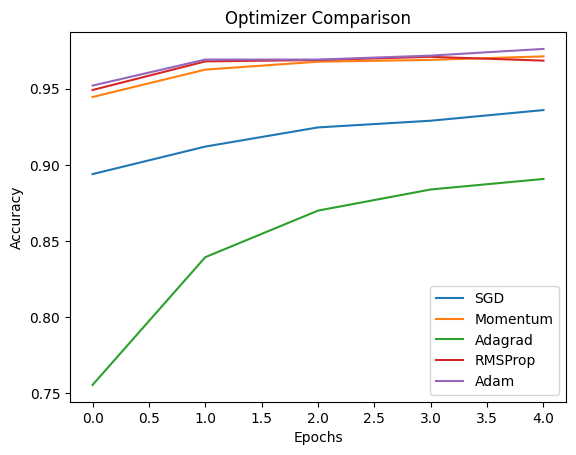

In [ ]:
plt.figure()

for name in history_dict:
    plt.plot(history_dict[name].history['val_accuracy'], label=name)

plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()